<a href="https://colab.research.google.com/github/dohee-jin/data-mining-final-project/blob/main/kbo_postseason_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 깃허브에 업로드한 2001-2025, 2026 팀 데이터 불러오기

In [191]:
import pandas as pd

# 2001-2025 팀 별 타자, 투수 데이터
team_hitter = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_hitter_2001-2025.csv")
team_pitcher = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_pitcher_2001-2025.csv")

# 역대 구단 성적
history = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_2001-2025.csv")

# 2026 r구단별 성적 ,팀별 타자, 투수 데이터
team_hitter_2026 = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_hitter_2026.csv")
team_pitcher_2026 = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_pitcher_2026.csv")
team_2026 = pd.read_csv("https://raw.githubusercontent.com/dohee-jin/data-mining-final-project/main/data/raw/kbo_team_stats_2026.csv")

print(team_hitter.columns)
print(team_pitcher.columns)
print(history.columns)
print(team_hitter_2026.columns)
print(team_pitcher_2026.columns)
print(team_2026.columns)


Index(['연도', '순위', '팀명', 'AVG', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'TB', 'RBI', 'SAC', 'SF', 'BB', 'IBB', 'HBP', 'SO', 'GDP', 'SLG', 'OBP',
       'OPS', 'MH', 'RISP', 'PH-BA'],
      dtype='object')
Index(['연도', '순위', '팀명', 'ERA', 'G', 'W', 'L', 'SV', 'HLD', 'WPCT', 'IP', 'H',
       'HR', 'BB', 'HBP', 'SO', 'R', 'ER', 'WHIP', 'CG', 'SHO', 'QS', 'BSV',
       'TBF', 'NP', 'AVG', '2B', '3B', 'SAC', 'SF', 'IBB', 'WP', 'BK'],
      dtype='object')
Index(['year', 'team', '경기', '승', '패', '무', '타율', '평균자책점', '승률'], dtype='object')
Index(['연도', '순위', '팀명', 'AVG', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'TB', 'RBI', 'SAC', 'SF', 'BB', 'IBB', 'HBP', 'SO', 'GDP', 'SLG', 'OBP',
       'OPS', 'MH', 'RISP', 'PH-BA'],
      dtype='object')
Index(['연도', '순위', '팀명', 'ERA', 'G', 'W', 'L', 'SV', 'HLD', 'WPCT', 'IP', 'H',
       'HR', 'BB', 'HBP', 'SO', 'R', 'ER', 'WHIP', 'CG', 'SHO', 'QS', 'BSV',
       'TBF', 'NP', 'AVG', '2B', '3B', 'SAC', 'SF', 'IBB', 'WP', 'BK'],
      

In [192]:
# 시즌별 순위 리스트
rank_data = [
    [2001, '두산', 1], [2001, '삼성', 2], [2001, '현대', 3], [2001, '한화', 4], [2001, 'KIA', 5], [2001, 'LG', 6], [2001, 'SK', 7], [2001, '롯데', 8],
    [2002, '삼성', 1], [2002, 'LG', 2], [2002, 'KIA', 3], [2002, '현대', 4], [2002, '두산', 5], [2002, 'SK', 6], [2002, '한화', 7], [2002, '롯데', 8],
    [2003, '현대', 1], [2003, 'SK', 2], [2003, 'KIA', 3], [2003, '삼성', 4], [2003, '한화', 5], [2003, 'LG', 6], [2003, '두산', 7], [2003, '롯데', 8],
    [2004, '현대', 1], [2004, '삼성', 2], [2004, '두산', 3], [2004, 'KIA', 4], [2004, 'SK', 5], [2004, 'LG', 6], [2004, '한화', 7], [2004, '롯데', 8],
    [2005, '삼성', 1], [2005, '두산', 2], [2005, 'SK', 3], [2005, '한화', 4], [2005, '롯데', 5], [2005, 'LG', 6], [2005, '현대', 7], [2005, 'KIA', 8],
    [2006, '삼성', 1], [2006, '한화', 2], [2006, '현대', 3], [2006, 'KIA', 4], [2006, '두산', 5], [2006, 'SK', 6], [2006, '롯데', 7], [2006, 'LG', 8],
    [2007, 'SK', 1], [2007, '두산', 2], [2007, '한화', 3], [2007, '삼성', 4], [2007, 'LG', 5], [2007, '현대', 6], [2007, '롯데', 7], [2007, 'KIA', 8],
    [2008, 'SK', 1], [2008, '두산', 2], [2008, '롯데', 3], [2008, '삼성', 4], [2008, '한화', 5], [2008, 'KIA', 6], [2008, '우리', 7], [2008, 'LG', 8],
    [2009, 'KIA', 1], [2009, 'SK', 2], [2009, '두산', 3], [2009, '롯데', 4], [2009, '삼성', 5], [2009, '히어로즈', 6], [2009, 'LG', 7], [2009, '한화', 8],
    [2010, 'SK', 1], [2010, '삼성', 2], [2010, '두산', 3], [2010, '롯데', 4], [2010, 'KIA', 5], [2010, 'LG', 6], [2010, '넥센', 7], [2010, '한화', 8],
    [2011, '삼성', 1], [2011, 'SK', 2], [2011, '롯데', 3], [2011, 'KIA', 4], [2011, '두산', 5], [2011, 'LG', 6], [2011, '한화', 7], [2011, '넥센', 8],
    [2012, '삼성', 1], [2012, 'SK', 2], [2012, '두산', 3], [2012, '롯데', 4], [2012, 'KIA', 5], [2012, '넥센', 6], [2012, 'LG', 7], [2012, '한화', 8],
    [2013, '삼성', 1], [2013, '두산', 2], [2013, 'LG', 3], [2013, '넥센', 4], [2013, '롯데', 5], [2013, 'SK', 6], [2013, 'NC', 7], [2013, 'KIA', 8], [2013, '한화', 9],
    [2014, '삼성', 1], [2014, '넥센', 2], [2014, 'NC', 3], [2014, 'LG', 4], [2014, 'SK', 5], [2014, '두산', 6], [2014, '롯데', 7], [2014, 'KIA', 8], [2014, '한화', 9],
    [2015, '두산', 1], [2015, '삼성', 2], [2015, 'NC', 3], [2015, '넥센', 4], [2015, 'SK', 5], [2015, '한화', 6], [2015, 'KIA', 7], [2015, '롯데', 8], [2015, 'LG', 9], [2015, 'KT', 10],
    [2016, '두산', 1], [2016, 'NC', 2], [2016, '넥센', 3], [2016, 'LG', 4], [2016, 'KIA', 5], [2016, 'SK', 6], [2016, '한화', 7], [2016, '롯데', 8], [2016, '삼성', 9], [2016, 'KT', 10],
    [2017, 'KIA', 1], [2017, '두산', 2], [2017, '롯데', 3], [2017, 'NC', 4], [2017, 'SK', 5], [2017, 'LG', 6], [2017, '넥센', 7], [2017, '한화', 8], [2017, '삼성', 9], [2017, 'KT', 10],
    [2018, 'SK', 1], [2018, '두산', 2], [2018, '한화', 3], [2018, '넥센', 4], [2018, 'KIA', 5], [2018, '삼성', 6], [2018, '롯데', 7], [2018, 'LG', 8], [2018, 'KT', 9], [2018, 'NC', 10],
    [2019, '두산', 1], [2019, '키움', 2], [2019, 'SK', 3], [2019, 'LG', 4], [2019, 'NC', 5], [2019, 'KT', 6], [2019, 'KIA', 7], [2019, '삼성', 8], [2019, '한화', 9], [2019, '롯데', 10],
    [2020, 'NC', 1], [2020, '두산', 2], [2020, 'KT', 3], [2020, 'LG', 4], [2020, '키움', 5], [2020, 'KIA', 6], [2020, '롯데', 7], [2020, '삼성', 8], [2020, 'SK', 9], [2020, '한화', 10],
    [2021, 'KT', 1], [2021, '두산', 2], [2021, '삼성', 3], [2021, 'LG', 4], [2021, '키움', 5], [2021, 'SSG', 6], [2021, 'NC', 7], [2021, '롯데', 8], [2021, 'KIA', 9], [2021, '한화', 10],
    [2022, 'SSG', 1], [2022, '키움', 2], [2022, 'LG', 3], [2022, 'KT', 4], [2022, 'KIA', 5], [2022, 'NC', 6], [2022, '삼성', 7], [2022, '롯데', 8], [2022, '두산', 9], [2022, '한화', 10],
    [2023, 'LG', 1], [2023, 'KT', 2], [2023, 'SSG', 3], [2023, 'NC', 4], [2023, '두산', 5], [2023, 'KIA', 6], [2023, '롯데', 7], [2023, '삼성', 8], [2023, '한화', 9], [2023, '키움', 10],
    [2024, 'KIA', 1], [2024, '삼성', 2], [2024, 'LG', 3], [2024, '두산', 4], [2024, 'KT', 5], [2024, 'SSG', 6], [2024, '롯데', 7], [2024, '한화', 8], [2024, 'NC', 9], [2024, '키움', 10],
    [2025, 'LG', 1], [2025, '한화', 2], [2025, 'SSG', 3], [2025, '삼성', 4], [2025, 'NC', 5], [2025, 'KT', 6], [2025, '롯데', 7], [2025, 'KIA', 8], [2025, '두산', 9], [2025, '키움', 10]
]

rank_df = pd.DataFrame(rank_data, columns=['year', 'team', 'rank'])
display(rank_df.head())

,year,team,rank
0,2001,두산,1
1,2001,삼성,2
2,2001,현대,3
3,2001,한화,4
4,2001,KIA,5


In [193]:
# 역대 구단성적에 포스트시즌 진출여부 붙이기

# 1. 팀명 통일하기
team_name_map = {
    "두산 베어스": "두산",
    "삼성 라이온즈": "삼성",
    "LG 트윈스": "LG",
    "KIA 타이거즈": "KIA",
    "롯데 자이언츠": "롯데",
    "한화 이글스": "한화",
    "SSG 랜더스": "SSG",
    "SK 와이번스": "SK",
    "키움 히어로즈": "키움",
    "넥센 히어로즈": "넥센",
    "우리 히어로즈": "우리",
    "히어로즈": "히어로즈",
    "NC 다이노스": "NC",
    "KT 위즈": "KT",
    "현대 유니콘스": "현대",
    "해태 타이거즈": "해태"
}

history["team"] = history["team"].replace(team_name_map)
team_2026["team"] = team_2026["team"].replace(team_name_map)

# 2. 역대 구단성적에 순위 붙이기
history = history.merge(rank_df, on=["year", "team"], how="left")

# 머지할 때 붙은 rank_x, rank_y 칼럼 지우기
# history = history.drop(columns=["rank_x", "rank_y"], errors="ignore")

# Rank 안 붙은 행 확인
history[history["rank"].isnull()][["year", "team"]]

,year,team


In [194]:
# 포스트시즌 진출 여부 라벨 붙이기
history["is_postseason"] = history["rank"].apply(lambda x: 1 if x <= 5 else 0)

history["is_postseason"].value_counts()

,count
is_postseason,
1,125
0,99


In [195]:
# rank 결측 확인
history[history["rank"].isnull()][["year", "team"]]

,year,team


## 데이터 전처리

In [196]:
# 데이터 전처리

# 1. 칼럼명 통일
print(team_hitter.columns)
print(team_pitcher.columns)
print(team_hitter_2026.columns)
print(team_pitcher_2026.columns)
print(history.columns)
print(team_2026.columns)

rename_columns = {
    "연도": "Year",
    "순위": "Rank",
    "팀명": "Team",
}

for df in [team_hitter, team_hitter_2026, team_pitcher, team_pitcher_2026]:
  df.rename(columns = rename_columns, inplace = True)

  # 학습 데이터의 순위 기록 지우기
  df.drop(columns=["Rank"], errors = "ignore", inplace=True)

rename_columns2 = {
    "year": "Year",
    "team": "Team",
    "경기": "G",
    "승": "W",
    "패": "L",
    "무": "D", # draw
    "타율": "AVG",
    "평균자책점": "ERA",
    "승률": "WinRate",
    "rank": "Rank"
}

for df in [team_2026, history]:
  df.rename(columns = rename_columns2, inplace = True)

for df in [team_2026, history, team_hitter, team_pitcher]:
    df["Team"] = df["Team"].replace(team_name_map)
    df["Team"] = df["Team"].astype(str).str.strip()
    df["Year"] = df["Year"].astype(int)

print("============")
print(team_hitter.columns)
print(team_pitcher.columns)
print(team_hitter_2026.columns)
print(team_pitcher_2026.columns)
print(history.columns)


Index(['연도', '순위', '팀명', 'AVG', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'TB', 'RBI', 'SAC', 'SF', 'BB', 'IBB', 'HBP', 'SO', 'GDP', 'SLG', 'OBP',
       'OPS', 'MH', 'RISP', 'PH-BA'],
      dtype='object')
Index(['연도', '순위', '팀명', 'ERA', 'G', 'W', 'L', 'SV', 'HLD', 'WPCT', 'IP', 'H',
       'HR', 'BB', 'HBP', 'SO', 'R', 'ER', 'WHIP', 'CG', 'SHO', 'QS', 'BSV',
       'TBF', 'NP', 'AVG', '2B', '3B', 'SAC', 'SF', 'IBB', 'WP', 'BK'],
      dtype='object')
Index(['연도', '순위', '팀명', 'AVG', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'TB', 'RBI', 'SAC', 'SF', 'BB', 'IBB', 'HBP', 'SO', 'GDP', 'SLG', 'OBP',
       'OPS', 'MH', 'RISP', 'PH-BA'],
      dtype='object')
Index(['연도', '순위', '팀명', 'ERA', 'G', 'W', 'L', 'SV', 'HLD', 'WPCT', 'IP', 'H',
       'HR', 'BB', 'HBP', 'SO', 'R', 'ER', 'WHIP', 'CG', 'SHO', 'QS', 'BSV',
       'TBF', 'NP', 'AVG', '2B', '3B', 'SAC', 'SF', 'IBB', 'WP', 'BK'],
      dtype='object')
Index(['year', 'team', '경기', '승', '패', '무', '타율', '평균자책점', '승률', '

In [197]:
# 이상치, 결측치 확인 or 문자형 -> 숫자형 변환
import numpy as np

# 결측치 확인 헬퍼 함수
def check_missing_markers(df, name):
  print("==== 결측치 확인 ====")

  for col in df.columns:
        if col not in ["Year", "Team"]:
            count_dash = (df[col].astype(str).str.strip() == "-").sum()
            count_blank = (df[col].astype(str).str.strip() == "").sum()

            if count_dash > 0 or count_blank > 0:
                print(col, " '-' 개수:", count_dash, " 빈칸 개수:", count_blank)

check_missing_markers(history, "history")
check_missing_markers(team_hitter, "team_hitter")
check_missing_markers(team_pitcher, "team_pitcher")

==== 결측치 확인 ====
==== 결측치 확인 ====
==== 결측치 확인 ====


In [198]:
# 숫자형 변환 전 IP의 이닝 표기 방법 변환
def convert_ip(value):
    value = str(value).strip()

    if " " in value:
        inning, fraction = value.split()
        inning = float(inning)

        if fraction == "1/3":
            return inning + 1/3
        elif fraction == "2/3":
            return inning + 2/3

    return float(value)


team_pitcher["IP"] = team_pitcher["IP"].apply(convert_ip)
team_pitcher_2026["IP"] = team_pitcher_2026["IP"].apply(convert_ip)

In [199]:
# 숫자형 변환
def convert_numeric_columns(df, exclude_cols=["Year", "Team"]):
    df = df.copy()

    for col in df.columns:
        if col not in exclude_cols:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip()
                .replace("-", np.nan)
                .replace("", np.nan)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

history = convert_numeric_columns(history)
team_hitter = convert_numeric_columns(team_hitter)
team_pitcher = convert_numeric_columns(team_pitcher)

In [200]:
# 변환 후 결측치 확인
print(history.isnull().sum().sort_values(ascending=False).head(20))
print(team_hitter.isnull().sum().sort_values(ascending=False).head(20))
print(team_pitcher.isnull().sum().sort_values(ascending=False).head(20))

Year             0
Team             0
G                0
W                0
L                0
D                0
AVG              0
ERA              0
WinRate          0
Rank             0
is_postseason    0
dtype: int64
Year    0
Team    0
AVG     0
G       0
PA      0
AB      0
R       0
H       0
2B      0
3B      0
HR      0
TB      0
RBI     0
SAC     0
SF      0
BB      0
IBB     0
HBP     0
SO      0
GDP     0
dtype: int64
WPCT    1
Year    0
ERA     0
Team    0
W       0
L       0
SV      0
G       0
HLD     0
IP      0
H       0
HR      0
BB      0
HBP     0
SO      0
R       0
ER      0
WHIP    0
CG      0
SHO     0
dtype: int64


In [201]:
# 결측치 행 확인
history[history.isnull().any(axis=1)]
team_hitter[team_hitter.isnull().any(axis=1)]
team_pitcher[team_pitcher.isnull().any(axis=1)]

,Year,Team,ERA,G,W,L,SV,HLD,WPCT,IP,...,TBF,NP,AVG,2B,3B,SAC,SF,IBB,WP,BK
194,2023,LG,3.67,144,86,56,37,92,NaN,1293.333333,...,5619,21814,0.256,215,17,64,42,15,47,5


In [202]:
# 2023 LG 의 WPCT 결측치 처리
team_pitcher[team_pitcher["WPCT"].isnull()][["Year", "Team", "W", "L", "WPCT"]]

# WPCT 계산해서 추가(WCPT = 승률)
team_pitcher["WPCT"] = team_pitcher["WPCT"].fillna(
    team_pitcher["W"] / (team_pitcher["W"] + team_pitcher["L"])
)

team_pitcher[team_pitcher["WPCT"].isnull()][["Year", "Team", "W", "L", "WPCT"]]

,Year,Team,W,L,WPCT


In [203]:
# 타자 이상치 확인
team_hitter.describe()

,Year,AVG,G,PA,AB,R,H,2B,3B,HR,...,IBB,HBP,SO,GDP,SLG,OBP,OPS,MH,RISP,PH-BA
count,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,...,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,2013.691964,0.270201,147.375000,5167.267857,4510.102679,678.040179,1224.142857,212.751317,19.270897,115.848107,...,17.834821,75.553571,919.633929,105.941964,0.403107,0.346478,0.749585,136.593750,0.272888,0.226469
std,7.209780,0.014225,54.441086,1044.919638,907.708697,112.968519,250.673205,50.392399,7.866197,42.216551,...,5.955323,18.031780,142.220160,14.453613,0.034398,0.014907,0.046737,7.275498,0.018599,0.036861
min,2001.000000,0.237000,126.000000,14.000000,49.000000,455.000000,75.000000,0.355000,0.305000,0.660000,...,5.000000,37.000000,628.000000,72.000000,0.336000,0.305000,0.658000,123.000000,0.224000,0.131000
25%,2007.750000,0.260000,133.000000,5042.750000,4372.250000,600.500000,1153.500000,196.000000,15.000000,90.000000,...,14.000000,62.000000,813.750000,94.750000,0.376000,0.336000,0.714750,132.000000,0.261000,0.202000
50%,2014.000000,0.270000,144.000000,5320.500000,4612.000000,669.000000,1251.000000,218.000000,19.000000,115.000000,...,17.000000,74.000000,918.000000,106.000000,0.399000,0.346000,0.746500,133.000000,0.272000,0.223500
75%,2020.000000,0.280000,144.000000,5650.000000,4949.000000,755.250000,1352.000000,239.500000,24.000000,143.000000,...,21.000000,87.250000,1021.500000,116.000000,0.428000,0.357000,0.781250,144.000000,0.284250,0.254000
max,2025.000000,0.309000,469.000000,5870.000000,5176.000000,1064.000000,1601.000000,304.000000,41.000000,234.000000,...,39.000000,136.000000,1286.000000,148.000000,0.509000,0.382000,0.891000,144.000000,0.330000,0.340000


In [204]:
# 투수 이상치 확인
team_pitcher.describe()

,Year,ERA,G,W,L,SV,HLD,WPCT,IP,H,...,TBF,NP,AVG,2B,3B,SAC,SF,IBB,WP,BK
count,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,...,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,2013.691964,4.469241,137.000000,67.080357,67.080357,32.428571,54.424107,0.500030,1217.599702,1263.156250,...,5349.433036,20694.575893,0.270228,220.232143,19.946429,70.834821,42.477679,17.834821,57.727679,3.866071
std,7.209780,0.632631,7.256974,11.023122,11.089233,6.805055,18.756011,0.077407,63.833553,127.065845,...,330.540602,1447.567752,0.014811,32.208954,6.712333,20.078421,9.454609,8.644158,15.133248,2.206779
min,2001.000000,3.220000,126.000000,35.000000,43.000000,13.000000,15.000000,0.265000,1102.333333,968.000000,...,4690.000000,17361.000000,0.233000,127.000000,6.000000,29.000000,18.000000,0.000000,21.000000,0.000000
25%,2007.750000,3.955000,133.000000,59.000000,58.750000,28.000000,40.000000,0.451750,1169.000000,1171.750000,...,5091.250000,19540.500000,0.260000,198.750000,16.000000,55.000000,36.000000,12.000000,47.000000,2.000000
50%,2014.000000,4.430000,133.000000,67.000000,67.500000,32.000000,54.500000,0.502000,1200.500000,1257.000000,...,5342.500000,20646.000000,0.270000,222.000000,19.000000,70.000000,42.000000,17.000000,56.000000,4.000000
75%,2020.000000,4.915000,144.000000,75.000000,74.000000,37.000000,66.000000,0.560000,1279.333333,1351.250000,...,5673.750000,22028.250000,0.280000,243.000000,23.000000,85.000000,48.000000,23.000000,67.000000,5.000000
max,2025.000000,6.350000,144.000000,93.000000,97.000000,51.000000,116.000000,0.659000,1301.333333,1593.000000,...,5937.000000,23328.000000,0.318000,315.000000,48.000000,121.000000,65.000000,44.000000,103.000000,11.000000


## 데이터 합치기
역대 구단성적, 2001-2025년 팀별 타자, 투수 데이터 합쳐서 학습에 필요한 하나의 데이터로 만드는 과정이 필요하다.

In [205]:
# 데이터 합치기
# 타자, 투수 데이터 칼럼 구분을 위해 접미사 붙이기
team_hitter = team_hitter.rename(
    columns={col: col + "_h" for col in team_hitter.columns if col not in ["Year", "Team"]}
)
team_pitcher = team_pitcher.rename(
    columns={col: col + "_p" for col in team_pitcher.columns if col not in ["Year", "Team"]}
)

team_df = history.merge(team_hitter, on=["Year", "Team"], how="left")
team_df = team_df.merge(team_pitcher, on=["Year", "Team"], how="left")

In [206]:
# 합쳐진 데이터 확인
team_df.head()

,Year,Team,G,W,L,D,AVG,ERA,WinRate,Rank,...,TBF_p,NP_p,AVG_p,2B_p,3B_p,SAC_p,SF_p,IBB_p,WP_p,BK_p
0,2001,두산,133,65,63,5,0.276,4.96,0.508,1,...,5282,20071,0.284,196,23,85,48,17,47,0
1,2001,삼성,133,81,52,0,0.277,4.39,0.609,2,...,5243,20128,0.265,207,13,76,37,20,38,8
2,2001,현대,133,72,57,4,0.268,4.34,0.558,3,...,5218,20097,0.277,219,26,78,37,8,54,1
3,2001,한화,133,61,68,4,0.275,4.82,0.473,4,...,5331,20774,0.280,238,26,73,45,44,57,5
4,2001,KIA,133,60,68,5,0.278,5.01,0.469,5,...,5207,19799,0.272,212,16,71,36,17,51,3


## 모델 학습

In [207]:
# 종속 변수, 독립변수 분리
drop_cols = ["Year", "Team", "Rank", "is_postseason"]

X = team_df.drop(columns = drop_cols, errors = "ignore")
y = team_df["is_postseason"]

In [208]:
# 결측치, 이상치 최종확인
X.select_dtypes(include="object").columns
X.isnull().sum().sort_values(ascending=False).head(20)

,0
G,0
W,0
L,0
D,0
AVG,0
ERA,0
WinRate,0
AVG_h,0
G_h,0
PA_h,0


In [222]:
# 비율 스탯은 그대로, 누적 스탯은 경기당(per-game)으로 정규화
rate_cols = {"AVG","ERA","WinRate","OBP","SLG","OPS","WPCT","WHIP","RISP","PH-BA",
             "AVG_h","OBP_h","SLG_h","OPS_h","RISP_h","PH-BA_h",
             "WPCT_p","ERA_p","WHIP_p","AVG_p"}

def to_per_game(df, feature_cols):
    out = df[feature_cols].astype(float).copy()
    g = df["G"].astype(float).values
    for c in feature_cols:
        if c != "G" and c not in rate_cols:
            out[c] = out[c].values / g
    return out

feature_cols = X.columns.tolist()
X        = to_per_game(team_df, feature_cols)      # 학습 데이터 재생성

In [223]:
# 학습 데이터, 테스트 데이터로 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [224]:
# 모델 학습
# 로지스틱 회귀, 의사결정트리, 퍼셉트론 활용

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(random_state=42))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("=" * 50)
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))


Logistic Regression
Accuracy: 0.8666666666666667
Confusion Matrix
[[18  2]
 [ 4 21]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        20
           1       0.91      0.84      0.88        25

    accuracy                           0.87        45
   macro avg       0.87      0.87      0.87        45
weighted avg       0.87      0.87      0.87        45

Decision Tree
Accuracy: 0.9111111111111111
Confusion Matrix
[[19  1]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        20
           1       0.96      0.88      0.92        25

    accuracy                           0.91        45
   macro avg       0.91      0.92      0.91        45
weighted avg       0.92      0.91      0.91        45

Perceptron
Accuracy: 0.9111111111111111
Confusion Matrix
[[19  1]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        

In [225]:
# 모델별 결과 확인
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Accuracy
0,Logistic Regression,0.866667
1,Decision Tree,0.911111
2,Perceptron,0.911111


세 모델 모두 정확도가 0.86 ~ 0.88인 것으로 확인했다. (정규화전)   
정규화 이후 퍼셉트론과 의사결정트리의 정확도가 0.91으로 상승한 것을 확인할 수 있다.  

정규화 전 의사결정트리로 모델 학습 후 2026 데이터로 예측했을 때 풀시즌으로 학습한 모델이 2026년도의 절반 시즌 기록을 제대로 예측하지 못하는 문제가 발생했다.   

따라서 기존 학습데이터와 2026 데이터의 스케일을 동일하게 맞추는 정규화를 진행했다. 경기 수에 따라 값이 누적되는 스탯(W, R, H, HR, IP, TBF 등)을 경기 수(G)로 나누어 경기당 비율로 변환했고 절반만 치른 2026년도 팀별 기록도 풀시즌과 같은 기준에서 비교할 수 있게 수정했다.   

수정후 세 모델의 학습 세부 지표를 확인했을때 의사결정트리와 퍼셉트론의 지표는 다음과 같으며 세 모델 중 정확도, marcor avg f1-score, weighted avg f1-score가 동일하게 높은 것으로 확인할 수 있다.
```
Decision Tree
Accuracy: 0.8888888888888888
Confusion Matrix
[[18  2]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        20
           1       0.92      0.88      0.90        25

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45
```
모델 학습 결과 의사결정트리와 퍼셉트론은 모두 정확도 0.9111을 기록하였으며, 포스트시즌 진출 팀에 대한 f1-score도 0.92로 동일하게 나타났다. 그러나 의사결정트리는 예측 기준을 비교적 쉽게 해석할 수 있고 변수 중요도 확인이 가능하다는 장점이 있으므로, 본 분석에서는 의사결정트리를 최종 모델로 선정하였다.

In [226]:
# 최종 모델: 의사결정트리
final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## 2026 포스트시즌 진출 예측
데이터는 2026-06-20일 데이터를 기준으로 확인한다.

### 잘못 예측한 데이터(기록용으로 남김)

In [213]:
# 2026 데이터도 현재까지의 팀 기록, 팀별 타자 투수 기록이 머지되어야 한다.
hitter = team_hitter_2026.rename(
    columns={col: col + "_h" for col in team_hitter_2026.columns if col not in ["Year", "Team"]}
)
pitcher = team_pitcher_2026.rename(
    columns={col: col + "_p" for col in team_pitcher_2026.columns if col not in ["Year", "Team"]}
)

team_df_2026 = team_2026.merge(hitter, on=["Year", "Team"], how="left")
team_df_2026 = team_df_2026.merge(pitcher, on=["Year", "Team"], how="left")

In [214]:
# 합쳐진 데이터 확인
team_df_2026.head()

,Year,Team,G,W,L,D,AVG,ERA,WinRate,AVG_h,...,TBF_p,NP_p,AVG_p,2B_p,3B_p,SAC_p,SF_p,IBB_p,WP_p,BK_p
0,2026,LG,70,44,26,0,0.270,4.32,0.629,0.270,...,2729,10553,0.271,102,10,19,21,4,26,1
1,2026,KT,69,41,27,1,0.285,4.64,0.603,0.285,...,2732,10430,0.277,105,11,27,21,12,33,0
2,2026,삼성,69,39,28,2,0.271,4.12,0.582,0.271,...,2690,10436,0.256,103,6,32,21,9,25,0
3,2026,KIA,71,37,33,1,0.263,4.08,0.529,0.263,...,2746,10826,0.251,97,6,28,15,11,23,2
4,2026,두산,71,34,35,2,0.264,4.01,0.493,0.264,...,2790,10849,0.263,120,9,38,25,6,33,2


In [215]:
# 입력데이터 만들기
X_2026 = team_df_2026[X.columns]

In [218]:
# 2026 포스트시즌 진출 여부 예측
team_df_2026["pred_postseason"] = final_model.predict(X_2026)
team_df_2026["postseason_probability"] = final_model.predict_proba(X_2026)[:, 1]

In [220]:
# 확률 높은 순으로 정렬
postseason_2026_result = team_df_2026.sort_values(
    "postseason_probability",
    ascending=False
)

postseason_2026_result[["Team", "pred_postseason", "postseason_probability"]]

,Team,pred_postseason,postseason_probability
9,키움,1,1.0
0,LG,0,0.0
1,KT,0,0.0
2,삼성,0,0.0
4,두산,0,0.0
3,KIA,0,0.0
5,한화,0,0.0
6,NC,0,0.0
7,롯데,0,0.0
8,SSG,0,0.0


상위 5개 팀을 선정해야 되는데 키움을 제외한 나머지 팀들의 진출 예측이 0인 것으로 보아 예측에 실패함을 확인할 수 있다.   

원인은 2001-2025의 풀시즌 기록으로 학습한 모델에 2026년도의 절반 누적된 기록을 넣었기 때문에 트리가 학습한 분기 임계값에 의해 절반만 마친 팀들이 낮은 쪽으로 빠져서 문제가 발생했다.   

해결방법은 학습 데이터와 2026 데이터의 스케일을 동일하게 맞추는 것이다.
경기 수에 따라 값이 누적되는 스탯(W, R, H, HR, IP, TBF 등)을 경기 수(G)로
나누어 경기당 비율로 변환하면, 절반만 치른 2026 팀의 기록도 풀시즌 기록과
같은 기준에서 비교할 수 있다. 반면 AVG, ERA, OPS, WHIP, 승률처럼 이미 비율로
계산된 스탯은 경기 수와 무관하게 일정하므로 그대로 둔다.

이때 정규화는 반드시 학습 데이터(X)와 예측 데이터(X_2026) 양쪽에 동일하게
적용해야 한다. 한쪽에만 적용하면 두 데이터의 스케일이 어긋나 같은 문제가
반복되기 때문이다.

정규화를 적용한 뒤 다시 예측한 결과, 승률 상위 팀이 진출(1), 하위 팀이
탈락(0)으로 구분되어 모델이 정상적으로 동작함을 확인할 수 있다.

### 다시 학습한 모델로 예측한 데이터

In [227]:
X_2026   = to_per_game(team_df_2026, feature_cols)

In [228]:
# 2026 포스트시즌 진출 여부 예측
team_df_2026["pred"] = final_model.predict(X_2026)
team_df_2026["prob"] = final_model.predict_proba(X_2026)[:, 1]

In [230]:
# 확률 높은 순으로 정렬
postseason_2026_result = team_df_2026.sort_values(
    "prob",
    ascending=False
)

postseason_2026_result[["Team", "pred", "prob"]]

,Team,pred,prob
0,LG,1,1.0
1,KT,1,1.0
2,삼성,1,1.0
3,KIA,1,1.0
4,두산,1,1.0
5,한화,1,1.0
6,NC,0,0.0
7,롯데,0,0.0
8,SSG,0,0.0
9,키움,0,0.0


재학습한 모델로 다시 예측했을 때   
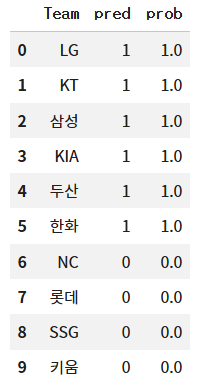

LG, KT, 삼성, KIA, 두산, 한화 6개의 팀이 포스트시즌 진출 가능성이 높다고 예측되었다. 포스트시즌은 5개 팀만 진출할 수 있기 때문에 로지스틱 회귀 모델을 통해 확률을 보조 정렬하였다.

In [232]:
log_model = models["Logistic Regression"]
log_model.fit(X_train, y_train)

team_df_2026["log_prob"] = log_model.predict_proba(X_2026)[:, 1]

team_df_2026.sort_values("log_prob", ascending=False)[
    ["Team", "pred", "prob", "log_prob"]
]

,Team,pred,prob,log_prob
0,LG,1,1.0,1.000000
2,삼성,1,1.0,1.000000
1,KT,1,1.0,0.999999
3,KIA,1,1.0,0.998555
5,한화,1,1.0,0.990769
6,NC,0,0.0,0.975569
4,두산,1,1.0,0.780970
7,롯데,0,0.0,0.023404
8,SSG,0,0.0,0.001633
9,키움,0,0.0,0.000001


## 포스트시즌 진출 예측 분석 보고서

### 1. 분석 목표

본 분석의 목표는 KBO 팀 성적 데이터를 활용하여 각 팀의 포스트시즌 진출 가능성을 예측하는 것이다. 포스트시즌 진출 여부는 팀의 최종 순위와 밀접한 관련이 있으며, 팀의 공격력과 투수력은 시즌 성적에 큰 영향을 주는 요소이다. 따라서 본 분석에서는 팀 타자 기록과 팀 투수 기록을 활용하여 포스트시즌 진출 여부를 이진 분류 문제로 구성하였다.

분석 대상은 2001년부터 2025년까지의 KBO 팀 기록이며, 정규시즌 순위를 기준으로 5위 이내 팀은 포스트시즌 진출 팀으로, 6위 이하 팀은 미진출 팀으로 라벨링하였다. 다만 KBO 포스트시즌 제도는 시기별로 차이가 있으므로, 본 프로젝트에서는 분석 기준을 단순화하기 위해 정규시즌 5위 이내 여부를 포스트시즌 진출 기준으로 정의하였다.

또한 2026년 데이터는 시즌이 진행 중인 기록이므로, 시즌 종료 기준 데이터와 단순 비교할 경우 누적 기록에서 차이가 발생할 수 있다. 이를 보완하기 위해 경기 수에 따라 누적되는 기록은 경기당 기록 또는 비율 형태로 변환하여 예측에 활용하였다.

### 2. 데이터 및 모델

본 분석에서는 KBO 공식 홈페이지에서 제공하는 역대 구단 성적, 팀 타자 기록, 팀 투수 기록을 활용하였다. 역대 구단 성적 데이터에서는 연도, 팀명, 경기 수, 승, 패, 무, 승률, 순위 정보를 사용하였고, 팀 타자 기록과 팀 투수 기록에서는 타율, 출루율, 장타율, OPS, 득점, 홈런, 평균자책점, WHIP, 탈삼진 등 팀의 경기력을 나타내는 지표를 사용하였다.

데이터 전처리 과정에서는 먼저 컬럼명을 분석에 적합하도록 영어 변수명으로 변경하였고, 팀명 표기를 통일하였다. 이후 문자열로 저장된 수치형 데이터를 숫자형으로 변환하였다. 특히 투수 기록의 IP 컬럼은 `1183 1/3`과 같이 분수 형태로 표기되어 있어 별도의 변환 함수를 적용하였다. 또한 WPCT처럼 분수 형태로 입력된 값은 승수와 패수를 활용하여 다시 계산하였다.

결측치와 이상치를 확인한 결과, 일부 원본 데이터 문제로 병합되지 않은 행이 있었으나 원본 데이터를 수정한 뒤 다시 병합하여 해결하였다. 이상치는 기초통계량을 통해 확인하였으며, 실제 팀 성적 차이를 반영한 값으로 판단되어 별도로 제거하지 않았다.

모델은 수업에서 학습한 분류 모델인 로지스틱 회귀, 의사결정트리, 퍼셉트론을 사용하였다. 로지스틱 회귀와 퍼셉트론은 변수의 크기에 영향을 받을 수 있으므로 표준화를 적용하였고, 의사결정트리는 별도의 표준화 없이 학습을 진행하였다.

### 3. 모델 선정 기준

모델 성능은 정확도, 혼동행렬, precision, recall, f1-score를 기준으로 비교하였다. 세 모델을 학습한 결과, 로지스틱 회귀는 정확도 0.8667을 기록하였고, 의사결정트리와 퍼셉트론은 각각 정확도 0.9111을 기록하였다.

의사결정트리와 퍼셉트론은 모두 동일한 정확도와 혼동행렬을 보였다. 두 모델 모두 실제 미진출 팀 20개 중 19개를 올바르게 예측하였고, 실제 진출 팀 25개 중 22개를 올바르게 예측하였다. 포스트시즌 진출 팀에 대한 f1-score도 0.92로 동일하게 나타났다.

최종 모델은 의사결정트리로 선정하였다. 의사결정트리는 퍼셉트론과 동일한 성능을 보였지만, 예측 과정에서 어떤 변수가 중요한 영향을 주었는지 해석하기 쉽다는 장점이 있다. 따라서 본 분석에서는 성능과 해석 가능성을 함께 고려하여 의사결정트리를 최종 모델로 사용하였다.

### 4. 결론 및 해석

최종 모델인 의사결정트리를 활용하여 2026년 팀 기록을 예측한 결과, LG, KT, 삼성, KIA, 두산, 한화가 포스트시즌 진출 가능성이 높은 팀으로 분류되었다. 다만 KBO 포스트시즌 진출 팀은 5개 팀이므로, 의사결정트리 결과만으로는 최종 5개 팀을 구분하기 어려운 한계가 있었다. 특히 의사결정트리는 예측 확률이 0 또는 1로 뚜렷하게 나오는 경향이 있어, 동일하게 진출 가능성이 높은 팀으로 분류된 팀들 간의 세부 순위를 구분하기 어렵다.

이를 보완하기 위해 로지스틱 회귀 모델의 예측 확률을 보조적으로 활용하였다. 로지스틱 회귀 결과에서는 한화와 NC가 각각 5위와 6위 수준으로 나타났으며, 한화가 NC보다 포스트시즌 진출 가능성이 높은 팀으로 해석되었다. 따라서 의사결정트리를 주요 분류 모델로 사용하되, 최종 5팀 선정에는 로지스틱 회귀의 예측 확률을 참고하였다.

최종적으로 2026년 현재 기록 기준 포스트시즌 진출 가능성이 높은 팀은 LG, 삼성, KT, KIA, 한화로 예측되었다. 이 결과는 현재까지의 팀 타격 및 투수 기록을 기반으로 한 예측이며, 시즌 종료 후 실제 순위와는 차이가 발생할 수 있다. 특히 2026년 데이터는 시즌이 진행 중인 기록이므로 부상, 외국인 선수 교체, 후반기 경기력 변화, 팀 분위기 등 기록으로 완전히 설명하기 어려운 요인은 반영하지 못한다는 한계가 있다.

그럼에도 불구하고 본 분석은 KBO 팀 기록을 활용하여 포스트시즌 진출 가능성을 데이터 기반으로 예측했다는 점에서 의미가 있다. 또한 누적 기록을 경기 수 기준 비율 지표로 변환하여 시즌 진행 중인 데이터에도 적용할 수 있도록 보완하였다는 점에서 단순한 순위 비교보다 분석적으로 확장된 결과를 도출할 수 있었다.
